###group project:###
Interpolation and in-painting for sparse neuroimaging data


*   5 methods:linear,Polynomial,Spline,Exponential,kriginig
*   5 frequency bands
*   evaluation strand:MSE,MAE,RMSE,R²

goal: interlopation using polynomail method

dataset:

*   coords.npy : <class 'numpy.ndarray'> stores EEG band power data in (1772, 3) format, where N is the number of measurement points, each with three spectral power values.
*   band_powers.npy : <class 'dict'> contains 3D coordinates (x, y, z) of measurement points in (1772, 3) format, used for spatial interpolation analysis







dataset visualization

In [6]:
import numpy as np
import matplotlib.pyplot as plt
samples = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()
print(type(samples))
print(type(band_powers))  # print the type of the dataset
print(band_powers.keys()) # print the band power

<class 'numpy.ndarray'>
<class 'dict'>
dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])


In [7]:
import numpy as np

# read the data
samples = np.load('coords.npy')
band_powers = np.load('band_powers.npy', allow_pickle=True).item()

# check the data structure
print(f"Electrode coordinate data shape: {samples.shape}")
print(f"First 10 lines of electrode coordinate data: \n{samples[:10]}")
print(f"Available frequency band: {band_powers.keys()}")

# choose Delta as example
delta_powers = np.array(band_powers['Delta'])
print(delta_powers.shape)

print(f"Delta Frequency band power data shape: {delta_powers.shape}")
print(f"Delta Top 10 values of frequency band power: {delta_powers[:5]}")


Electrode coordinate data shape: (1772, 3)
First 10 lines of electrode coordinate data: 
[[-56. -37.  -2.]
 [-60. -37.  -4.]
 [-63. -37.  -2.]
 [-68. -38.  -2.]
 [ -1.  42. -14.]
 [ -4.  42. -14.]
 [ -8.  42. -13.]
 [-12.  43. -13.]
 [-34. -33.   8.]
 [-38. -33.  10.]]
Available frequency band: dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
(1772,)
Delta Frequency band power data shape: (1772,)
Delta Top 10 values of frequency band power: [0.10527825 0.12613966 0.11567981 0.13830112 0.15696394]


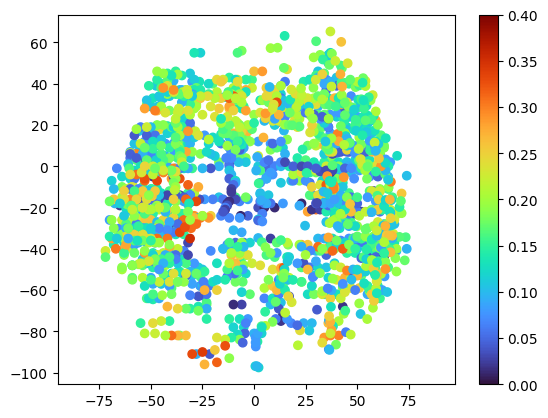

In [8]:
import numpy as np
import matplotlib.pyplot as plt

samples = np.load('coords.npy') #load the data coords
band_powers = np.load('band_powers.npy',allow_pickle=True).item() #load the data band_powers
plt.scatter(samples[:,0],samples[:,1],c=band_powers['Delta'],
            cmap='turbo',vmin=0,vmax=0.4) #show the x and y plane
plt.axis('equal')
plt.colorbar()

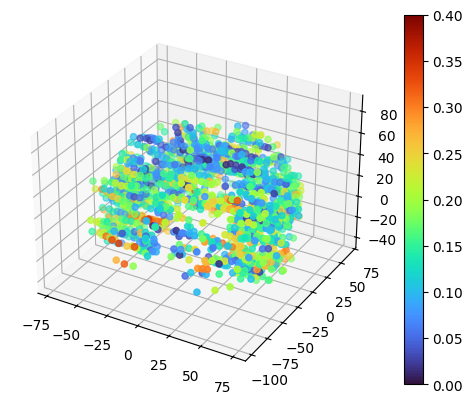

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(samples[:,0], samples[:,1], samples[:,2],
                c=band_powers['Delta'], cmap='turbo', vmin=0, vmax=0.4) #3D visualization
plt.colorbar(sc)
plt.show()

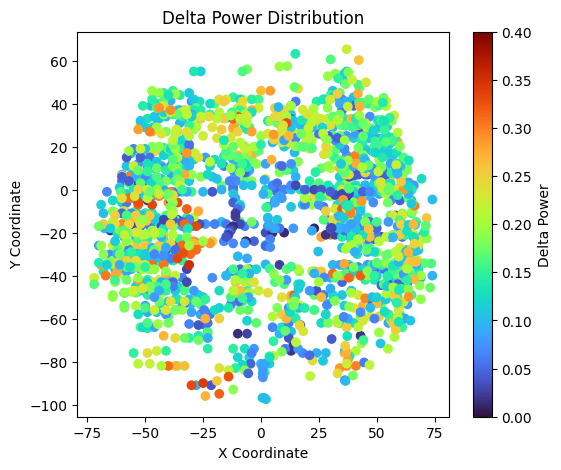

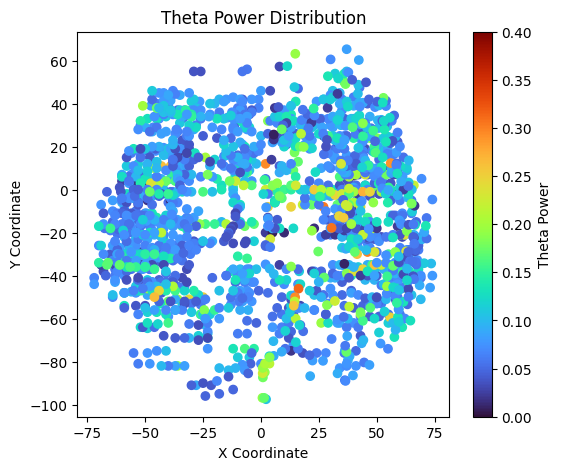

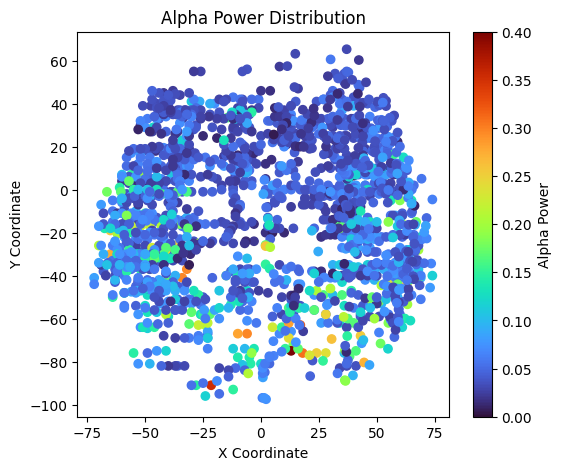

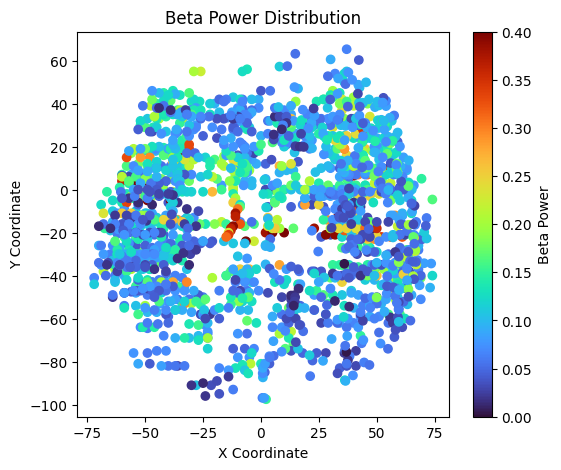

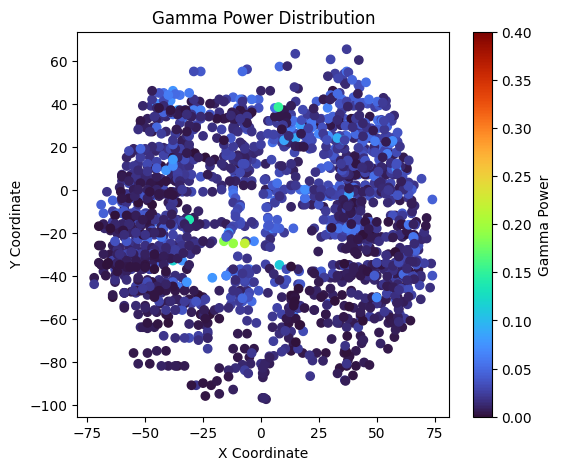

In [10]:
import matplotlib.pyplot as plt

# Visualization of different frequency bands
for freq in ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']:
    plt.figure(figsize=(6, 5))
    plt.scatter(samples[:,0], samples[:,1], c=band_powers[freq], cmap='turbo', vmin=0, vmax=0.4) # x and y plane
    plt.colorbar(label=f"{freq} Power")
    plt.title(f"{freq} Power Distribution")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.show()


Delta


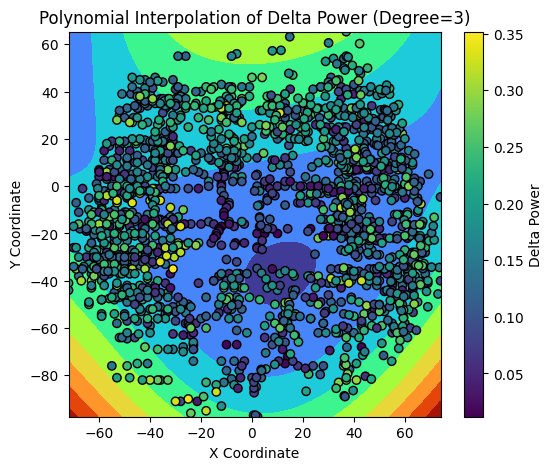

Theta


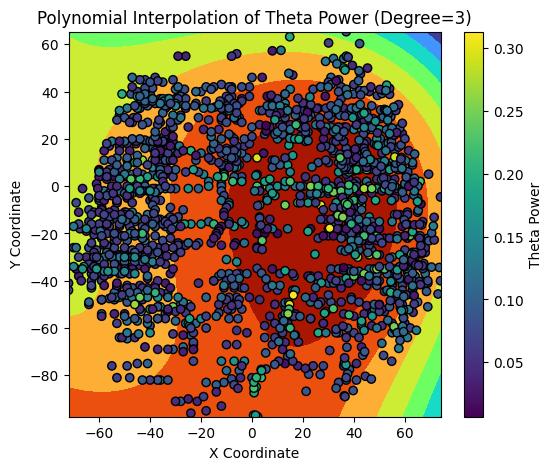

Alpha


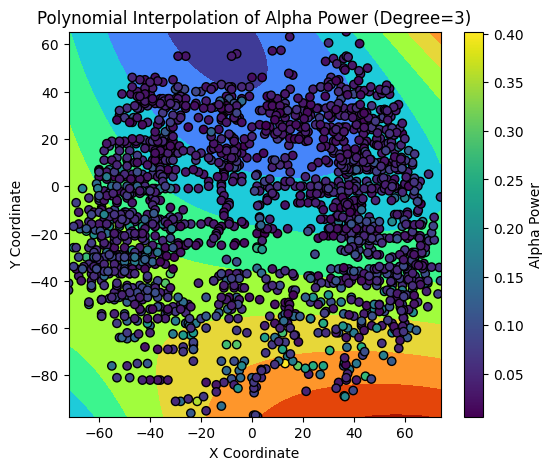

Beta


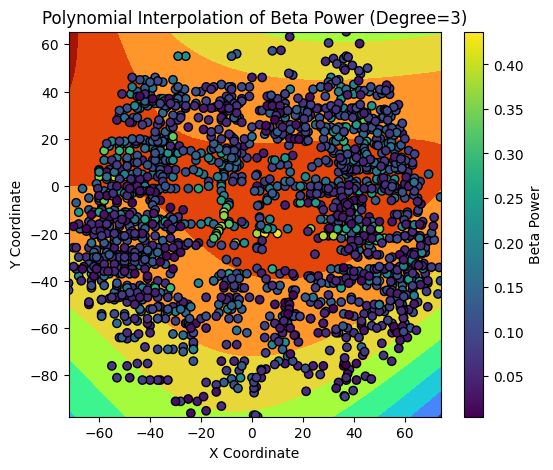

Gamma


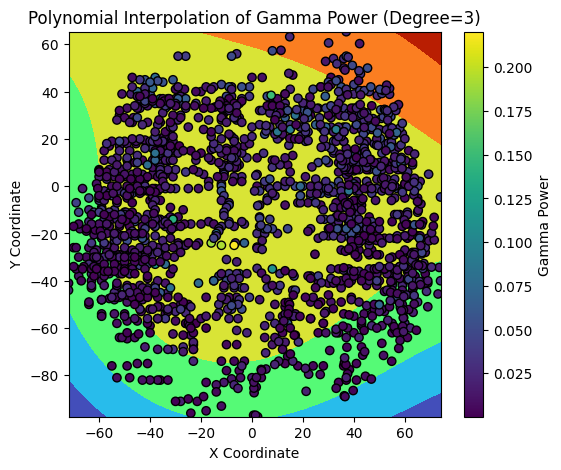


 result：

🔹 Delta band power:
   MSE:  0.004544
   MAE:  0.055356
   RMSE: 0.067410
   R²:   0.054790

🔹 Theta band power:
   MSE:  0.002350
   MAE:  0.036327
   RMSE: 0.048480
   R²:   0.021122

🔹 Alpha band power:
   MSE:  0.001976
   MAE:  0.030208
   RMSE: 0.044447
   R²:   0.168183

🔹 Beta band power:
   MSE:  0.004819
   MAE:  0.051572
   RMSE: 0.069421
   R²:   0.060117

🔹 Gamma band power:
   MSE:  0.000303
   MAE:  0.011966
   RMSE: 0.017416
   R²:   0.097778


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# read the data
samples = np.load('coords.npy')  # 3D coordinate data
band_powers = np.load('band_powers.npy', allow_pickle=True).item()  # EEG band power data

# coordinate
x_values = samples[:, 0]  # X
y_values = samples[:, 1]  # Y

# Select the order of the polynomial
degree = 3

# construct the binary polynomial eigenmatrix
def polynomial_features(x, y, degree):
    """
    generate a binary polynomial eigenmatrix for least squares fitting.
    """
    features = []
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            features.append((x ** i) * (y ** j))
    return np.vstack(features).T

# generate the interpolation network
grid_x, grid_y = np.meshgrid(np.linspace(min(x_values), max(x_values), 100),
                             np.linspace(min(y_values), max(y_values), 100))

# creat a list to save the evaluate result
evaluation_results = {}

# traverse all the band power
for freq in ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']:
    print(freq)

    # Extraction target value (EEG power)
    z_values = band_powers[freq]

    # Computational eigenmatrix
    X_poly = polynomial_features(x_values, y_values, degree)

    # Calculate polynomial coefficients (least square method)
    coeffs, _, _, _ = np.linalg.lstsq(X_poly, z_values, rcond=None)

    # Computed the value of interpolation
    grid_z = np.zeros_like(grid_x)
    index = 0
    for i in range(degree + 1):
        for j in range(degree + 1 - i):
            grid_z += coeffs[index] * (grid_x ** i) * (grid_y ** j)
            index += 1

    # calculate the error
    fitted_values = []
    for i in range(len(x_values)):
        idx_x = (np.abs(grid_x[0, :] - x_values[i])).argmin()
        idx_y = (np.abs(grid_y[:, 0] - y_values[i])).argmin()
        fitted_values.append(grid_z[idx_y, idx_x])  # chose the nearest interpolation

    # evaluation strand
    mse = mean_squared_error(z_values, fitted_values)
    mae = mean_absolute_error(z_values, fitted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(z_values, fitted_values)

    # save the evaluated data
    evaluation_results[freq] = {"MSE": mse, "MAE": mae, "RMSE": rmse, "R²": r2}

    # visualization
    plt.figure(figsize=(6, 5))
    plt.contourf(grid_x, grid_y, grid_z, cmap='turbo')
    plt.scatter(x_values, y_values, c=z_values, edgecolor='black', marker='o')
    plt.colorbar(label=f"{freq} Power")
    plt.title(f"Polynomial Interpolation of {freq} Power (Degree={degree})")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.show()

# print the evaluated result
print("\n result：")
for freq, metrics in evaluation_results.items():
    print(f"\n🔹 {freq} band power:")
    print(f"   MSE:  {metrics['MSE']:.6f}")
    print(f"   MAE:  {metrics['MAE']:.6f}")
    print(f"   RMSE: {metrics['RMSE']:.6f}")
    print(f"   R²:   {metrics['R²']:.6f}")
